# Phase 8  -  Random Forest classifier

**Research questions addressed:**
- **Q1** (multi-class): Can defence system repertoire classify species?
  Which features drive the classification?
- **Q2** (binary, per species): Can defence profile predict high-ARG burden?

**Methodology highlights:**
- All evaluation uses `StratifiedGroupKFold` (5-fold, groups = Mash phylogroups from NB04)
- Specificity-filtered feature set: 359 dp_* features (8 taxonomic markers removed from 367)
- Feature importance: Gini (MDI) -> Permutation -> SHAP TreeExplainer
- Comparison to NB05 LR baseline: improvement justified only if delta BA > margin of CI overlap

## Section 1  -  Imports and configuration

In [1]:
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # non-interactive backend (server/CI safe)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    balanced_accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
import shap
import warnings
warnings.filterwarnings("ignore")

ROOT  = Path("..")
PROC  = ROOT / "data" / "processed"
RES   = ROOT / "results"
FIG   = RES / "figures" / "rf"
FIG.mkdir(parents=True, exist_ok=True)
(RES / "models").mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS     = 5
N_BOOT       = 2000      # bootstrap replicates for CIs

print("Imports OK.")


Imports OK.


## Section 2  -  Load data and feature selection

Feature matrix and specificity-filtered feature set (359 dp_* columns, 8 taxonomic markers removed at score >= 0.70) derived identically to NB05 to ensure a comparable feature space across models.


In [2]:
fm      = pd.read_parquet(PROC / "feature_matrix_3335.parquet")
X_full  = fm                          # keep full df for label access

# Specificity filter (identical to Phase 7)
dp_cols    = sorted([c for c in fm.columns if c.startswith("dp_")])
sp_prev    = fm.groupby("species")[dp_cols].mean()   # 6 × 367
spec_score = sp_prev.std() / 0.5
markers    = spec_score[spec_score >= 0.70].index.tolist()
FEAT_COLS  = [c for c in dp_cols if c not in markers]

# Labels and group assignments
# .to_numpy() required: parquet loads string columns as PyArrow-backed ArrowStringArray.
# sklearn's GridSearchCV/CV splitters need plain numpy arrays for indexing.
y_q1   = fm["species"].to_numpy(dtype=str)     # 6-class label for Q1
groups = fm["phylogroup"].to_numpy(dtype=str)  # 309 phylogroups from Mash (NB04)

X = fm[FEAT_COLS].to_numpy(dtype=float)        # explicit float numpy array

print(f"Feature matrix: {X.shape[0]} genomes × {X.shape[1]} features")
print(f"Markers removed: {len(markers)} → {markers}")
print(f"\nSpecies distribution:")
for sp, n in fm["species"].value_counts().items():
    print(f"  {sp:<20} {n:>4}")
print(f"\nPhylogroups: {len(set(groups))} total, "
      f"max={pd.Series(groups).value_counts().max()}, "
      f"median={pd.Series(groups).value_counts().median():.0f}")


Feature matrix: 3335 genomes × 359 features
Markers removed: 8 → ['dp_AbiE', 'dp_PD-T4-6', 'dp_VSPR', 'dp_df_gcu233', 'dp_padloc_PDC-S04', 'dp_padloc_PDC-S07', 'dp_padloc_PDC-S12', 'dp_padloc_SoFic']

Species distribution:
  paeruginosa           600
  saureus               600
  abaumannii            600
  efaecium              524
  ecloaceae             507
  kpneumoniae           504

Phylogroups: 309 total, max=291, median=5


## Section 3  -  GroupedStratifiedKFold setup

`StratifiedGroupKFold(5)` on 309 Mash phylogroups; identical CV setup to NB05.


In [3]:
# Reuse identical CV object as Phase 7
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Verify fold structure
fold_sizes = []
for fold_i, (tr, te) in enumerate(cv.split(X, y_q1, groups=groups)):
    fold_sizes.append(len(te))
    species_in_test  = len(set(groups[te]))
    print(f"  Fold {fold_i+1}: {len(tr):>3} train | {len(te):>3} test "
          f"| {species_in_test} phylogroups in test")

print(f"\nFold size range: {min(fold_sizes)}–{max(fold_sizes)} genomes "
      f"(CV={np.std(fold_sizes)/np.mean(fold_sizes)*100:.1f}%)")


  Fold 1: 2503 train | 832 test | 63 phylogroups in test
  Fold 2: 2709 train | 626 test | 60 phylogroups in test
  Fold 3: 2710 train | 625 test | 62 phylogroups in test
  Fold 4: 2707 train | 628 test | 58 phylogroups in test
  Fold 5: 2711 train | 624 test | 66 phylogroups in test

Fold size range: 624–832 genomes (CV=12.4%)


## Section 4  -  Quick RF with default parameters (Q1)

**Key defaults in scikit-learn's RandomForestClassifier:**
- `n_estimators=100`  -  100 trees
- `max_features="sqrt"`  -  sqrt(359) approx 19 features sampled per split
- `max_depth=None`  -  trees grow until all leaves are pure
- `min_samples_leaf=1`  -  a leaf can contain a single genome

`class_weight="balanced"` added to correct for unequal fold sizes. `oob_score=True` provides a free internal accuracy estimate from the ~37% bootstrap holdout per tree.


In [4]:
# Quick RF  -  default params + balanced class weights + OOB
rf_default = RandomForestClassifier(
    n_estimators  = 100,
    max_features  = "sqrt",
    max_depth     = None,
    min_samples_leaf = 1,
    class_weight  = "balanced",
    oob_score     = True,          # free internal validation
    n_jobs        = -1,
    random_state  = RANDOM_STATE,
)

# Train on ALL data to get OOB score (OOB uses the full training set)
rf_default.fit(X, y_q1)
print(f"OOB balanced accuracy (all {len(X)} genomes): {rf_default.oob_score_:.4f}")
print()

# Also run the same model under grouped CV (apples-to-apples with Phase 7 LR)
import sys as _sys
_sys.path.insert(0, str(Path("..") / "src"))
from evaluation.bootstrap import bootstrap_ci_auto as _bootstrap_ci_auto
from evaluation.bootstrap import genome_bootstrap_ci as _genome_bci

def bootstrap_ci(y_true, y_pred, groups_arg=None, metric_fn=None, n_boot=N_BOOT, seed=42):
    """
    Cluster bootstrap CI where n_phylogroups >= 15 (Q1, Q2-EC/KP/PA).
    Falls back to genome-level bootstrap when n_phylogroups < 15 (EF, SA, AB).
    Wrapper maintains the original (mean, lo, hi) return convention.
    """
    if metric_fn is None:
        metric_fn = balanced_accuracy_score
    mean_val = metric_fn(y_true, y_pred)
    if groups_arg is None:
        lo, hi = _genome_bci(y_true, y_pred, metric_fn, n_boot, seed)
    else:
        lo, hi, _ = _bootstrap_ci_auto(y_true, y_pred, groups_arg, metric_fn, n_boot, seed)
    return mean_val, lo, hi


ba_scores = []
yt_def = np.empty(len(y_q1), dtype=object)
yp_def = np.empty(len(y_q1), dtype=object)
for tr, te in cv.split(X, y_q1, groups=groups):
    rf_default.fit(X[tr], y_q1[tr])
    pred = rf_default.predict(X[te])
    yt_def[te] = y_q1[te]
    yp_def[te] = pred
    ba_scores.append(balanced_accuracy_score(y_q1[te], pred))

mean_ba, lo, hi = bootstrap_ci(yt_def, yp_def)
print(f"Grouped CV balanced accuracy (5-fold): {mean_ba:.4f} [{lo:.4f}–{hi:.4f}]")
print(f"NB05 LR reference (filtered, grouped):   0.9040 [0.8940–0.9130]")
print()
delta = mean_ba - 0.9040
print(f"Delta RF_default vs LR: {delta:+.4f}")


OOB balanced accuracy (all 3335 genomes): 0.9691



Grouped CV balanced accuracy (5-fold): 0.8730 [0.8626–0.8827]
NB05 LR reference (filtered, grouped):   0.9040 [0.8940–0.9130]

Delta RF_default vs LR: -0.0310


## Section 5  -  Hyperparameter tuning with GridSearchCV

Grid search over `n_estimators` {100, 300}, `max_depth` {10, 20, None}, `min_samples_leaf` {1, 3, 5}, and `max_features` {sqrt, 0.3}; 36 combinations evaluated under the same `StratifiedGroupKFold(5)` CV used throughout to prevent hyperparameter leakage. Scoring metric: balanced accuracy.


In [5]:
param_grid = {
    "n_estimators"    : [100, 300],
    "max_depth"       : [10, 20, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features"    : ["sqrt", 0.3],
}

rf_base = RandomForestClassifier(
    class_weight = "balanced",
    oob_score    = False,   # off during grid search (slow)
    n_jobs       = 1,       # n_jobs=1 inside RF; GridSearchCV handles outer parallelism
    random_state = RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = cv,                    # our phylo-grouped splitter
    scoring    = "balanced_accuracy",
    n_jobs     = -1,                    # parallelise across param combinations × folds
    verbose    = 1,
    refit      = True,                  # refit best model on full data
)

grid_search.fit(X, y_q1, groups=groups)

print("\nBest hyperparameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<22} {v}")
print(f"\nBest CV balanced accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits



Best hyperparameters:
  max_depth              None
  max_features           sqrt
  min_samples_leaf       1
  n_estimators           300

Best CV balanced accuracy: 0.8998


## Section 6  -  Final RF evaluation (grouped CV, Q1)

Best hyperparameters from Section 5 applied under `StratifiedGroupKFold(5)`; balanced accuracy and macro-F1 reported with 2000-resample bootstrap CIs and compared against the NB05 LR baseline.


In [6]:
best_params = grid_search.best_params_

rf_best = RandomForestClassifier(
    **best_params,
    class_weight = "balanced",
    oob_score    = True,
    n_jobs       = -1,
    random_state = RANDOM_STATE,
)

# Grouped CV  -  collect per-fold BA, F1, and all predictions for confusion matrix
ba_scores, f1_scores = [], []
yt_q1 = np.empty(len(y_q1), dtype=object)
yp_q1 = np.empty(len(y_q1), dtype=object)

for tr, te in cv.split(X, y_q1, groups=groups):
    rf_best.fit(X[tr], y_q1[tr])
    pred = rf_best.predict(X[te])
    yt_q1[te] = y_q1[te]
    yp_q1[te] = pred
    ba_scores.append(balanced_accuracy_score(y_q1[te], pred))
    f1_scores.append(f1_score(y_q1[te], pred, average="macro"))

all_true = list(yt_q1)   # for confusion matrix / classification_report downstream
all_pred = list(yp_q1)

mean_ba, lo_ba, hi_ba = bootstrap_ci(yt_q1, yp_q1, groups_arg=groups)
mean_f1, lo_f1, hi_f1 = bootstrap_ci(yt_q1, yp_q1, groups_arg=groups,
                                       metric_fn=lambda yt, yp: f1_score(yt, yp, average="macro"))
# Save per-genome Q1 RF predictions for future recomputation
np.save(RES / 'q1_rf_pred_true.npy', np.array(yt_q1))
np.save(RES / 'q1_rf_pred_pred.npy', np.array(yp_q1))
np.save(RES / 'q1_rf_pred_groups.npy', np.array(groups))

print("=== Q1 Random Forest (best params, grouped CV) ===")
print(f"Balanced accuracy: {mean_ba:.4f} [{lo_ba:.4f}–{hi_ba:.4f}]")
print(f"Macro F1:          {mean_f1:.4f} [{lo_f1:.4f}–{hi_f1:.4f}]")
print()
print("NB05 LR reference: BA=0.9040 [0.8940–0.9130]")
print(f"Delta RF vs LR (BA):  {mean_ba - 0.9040:+.4f}")

# OOB score (train on all data)
rf_best.fit(X, y_q1)
oob = rf_best.oob_score_
print(f"\nOOB score (full dataset, best RF): {oob:.4f}")
print(f"Grouped CV BA:                      {mean_ba:.4f}")
print(f"OOB - CV delta:                    {oob - mean_ba:+.4f}")
print()
print("The {:.1f}pp OOB-to-CV gap is the empirical phylogenetic".format(
    (oob - mean_ba) * 100))
print("correction effect. OOB uses random held-out trees (equivalent to standard")
print("CV) -- related genomes can bleed between training and test sets, inflating")
print("accuracy to {:.3f}. GroupedStratifiedKFold enforces clone-complete fold".format(oob))
print("isolation, removing that leak and giving the honest estimate of {:.3f}.".format(mean_ba))
print("The delta ({:+.1f}pp) quantifies how much phylogenetic signal standard CV".format(
    (oob - mean_ba) * 100))
print("would falsely claim as model performance on this dataset.")

# Per-class report
from sklearn.metrics import classification_report
print("\nPer-class metrics (pooled across CV folds):")
print(classification_report(all_true, all_pred, digits=3))


=== Q1 Random Forest (best params, grouped CV) ===
Balanced accuracy: 0.8953 [0.8711–0.9227]
Macro F1:          0.8918 [0.8518–0.9250]

NB05 LR reference: BA=0.9040 [0.8940–0.9130]
Delta RF vs LR (BA):  -0.0087



OOB score (full dataset, best RF): 0.9718
Grouped CV BA:                      0.8953
OOB - CV delta:                    +0.0766

The 7.7pp OOB-to-CV gap is the empirical phylogenetic
correction effect. OOB uses random held-out trees (equivalent to standard
CV) -- related genomes can bleed between training and test sets, inflating
accuracy to 0.972. GroupedStratifiedKFold enforces clone-complete fold
isolation, removing that leak and giving the honest estimate of 0.895.
The delta (+7.7pp) quantifies how much phylogenetic signal standard CV
would falsely claim as model performance on this dataset.

Per-class metrics (pooled across CV folds):
              precision    recall  f1-score   support

  abaumannii      0.947     0.683     0.794       600
   ecloaceae      0.875     0.901     0.888       507
    efaecium      0.729     0.985     0.838       524
 kpneumoniae      0.968     0.909     0.938       504
 paeruginosa      0.899     0.893     0.896       600
     saureus      0.995   

## Section 7  -  Confusion matrix

Per-class confusion from pooled grouped CV predictions; off-diagonal entries identify which species pairs the classifier conflates.

Saved: results/figures/rf/q1_rf_confusion_matrix.png

Normalised confusion matrix (row = true class):
             abaumannii  ecloaceae  efaecium  kpneumoniae  paeruginosa  saureus
abaumannii        0.683      0.025     0.230        0.002        0.060    0.000
ecloaceae         0.014      0.901     0.026        0.024        0.036    0.000
efaecium          0.002      0.000     0.985        0.000        0.008    0.006
kpneumoniae       0.004      0.069     0.014        0.909        0.004    0.000
paeruginosa       0.022      0.025     0.057        0.003        0.893    0.000
saureus           0.000      0.000     0.000        0.000        0.000    1.000


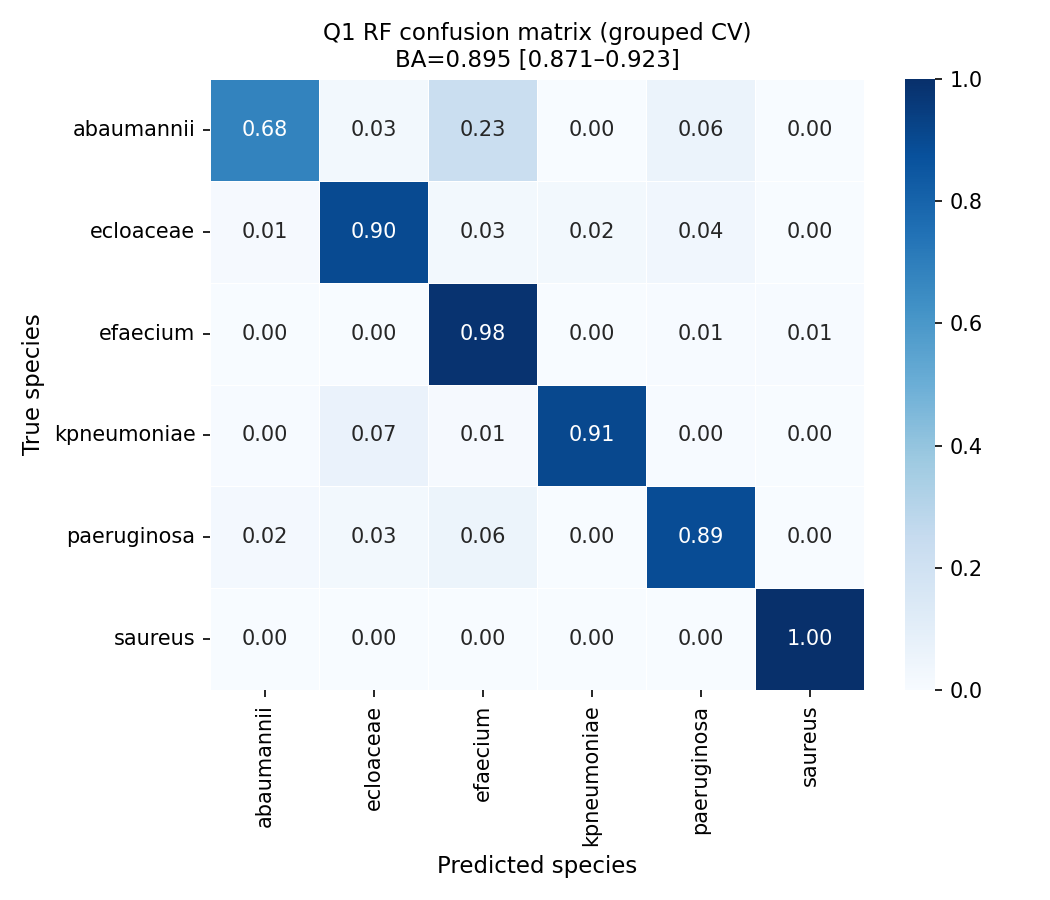

In [7]:
species_order = sorted(set(all_true))
cm = confusion_matrix(all_true, all_pred, labels=species_order, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=species_order, yticklabels=species_order,
    linewidths=0.4, linecolor="white", ax=ax,
    vmin=0, vmax=1,
)
ax.set_xlabel("Predicted species", fontsize=11)
ax.set_ylabel("True species", fontsize=11)
ax.set_title(f"Q1 RF confusion matrix (grouped CV)\nBA={mean_ba:.3f} [{lo_ba:.3f}–{hi_ba:.3f}]",
             fontsize=11)
plt.tight_layout()
fig.savefig(FIG / "q1_rf_confusion_matrix.png", dpi=150)
display(fig)
plt.close()
print("Saved: results/figures/rf/q1_rf_confusion_matrix.png")

# Print the confusion as a readable table
cm_df = pd.DataFrame(cm, index=species_order, columns=species_order).round(3)
print("\nNormalised confusion matrix (row = true class):")
print(cm_df.to_string())


## Section 8  -  Feature importance: Gini (Mean Decrease in Impurity)

Top 20 features ranked by mean impurity reduction across all trees; count features (highlighted) carry a known upward bias relative to binary features.

Saved: results/figures/rf/q1_rf_gini_importance.png

Top 10 features by Gini importance:
  dp_df_FS_Sma                                  0.04778
  dp_df_Abi2                                    0.04323
  dp_padloc_PDC-S13                             0.04274
  dp_SspBCDE                                    0.03315
  dp_PD-T4-3                                    0.03068
  dp_padloc_PDC-M24                             0.03041
  dp_RM_Type_IV                                 0.02929
  dp_df_Mok_Hok_Sok                             0.02720
  dp_padloc_PDC-S05                             0.02210
  dp_padloc_PDC-S02                             0.02105


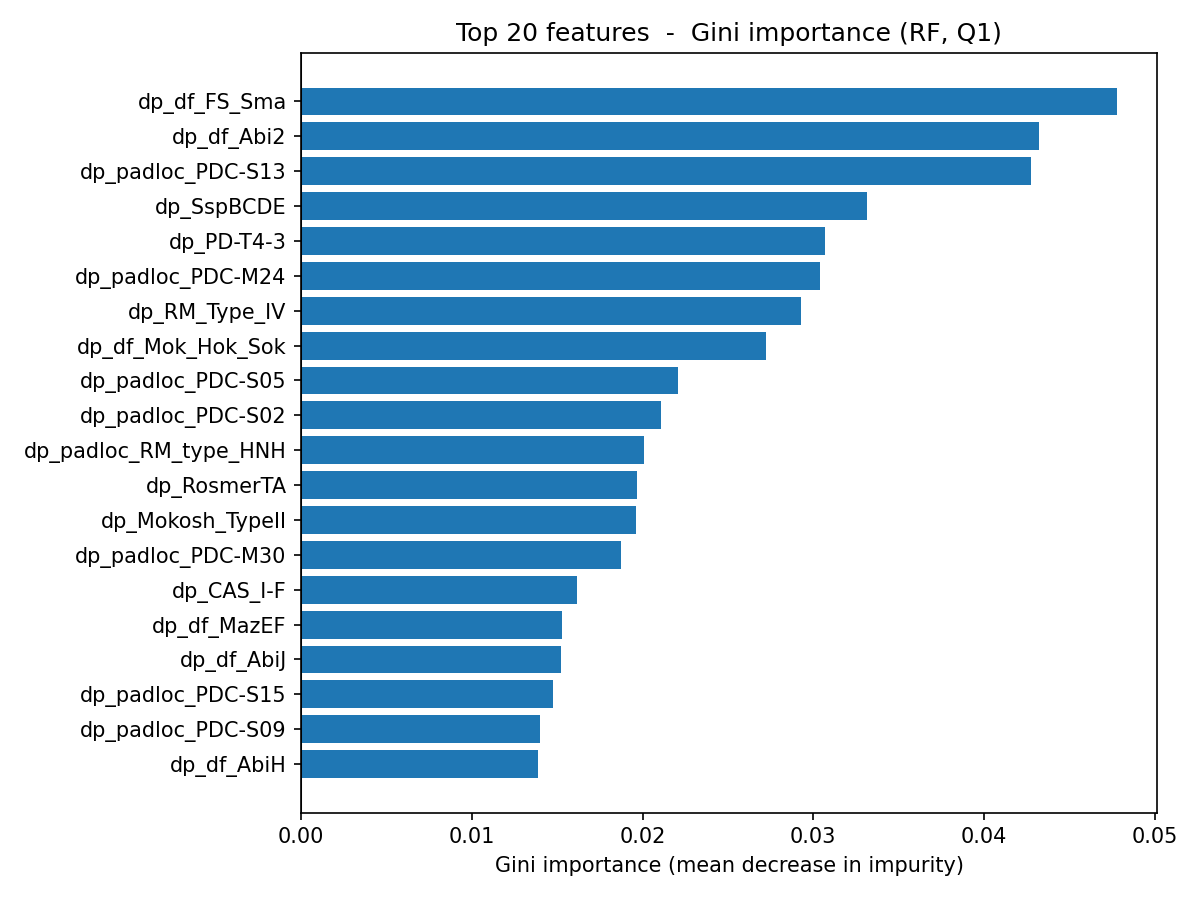

In [8]:
# rf_best was last fit on full X (for OOB). Retrain for importance on filtered set.
rf_best.fit(X, y_q1)

imp_gini = pd.Series(rf_best.feature_importances_, index=FEAT_COLS).sort_values(ascending=False)
top20 = imp_gini.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#d62728" if "count" in n or "ratio" in n else "#1f77b4" for n in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title("Top 20 features  -  Gini importance (RF, Q1)")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
fig.savefig(FIG / "q1_rf_gini_importance.png", dpi=150)
display(fig)
plt.close()
print("Saved: results/figures/rf/q1_rf_gini_importance.png")
print("\nTop 10 features by Gini importance:")
for f, v in imp_gini.head(10).items():
    print(f"  {f:<45} {v:.5f}")


## Section 9  -  Feature importance: Permutation importance

Mean decrease in balanced accuracy when each feature is randomly shuffled, averaged across all 5 grouped CV folds (30 repeats per fold); std bars reflect fold-to-fold variation. Unbiased by feature cardinality unlike Gini MDI.

Fold 1/5: train=2503, test=832  

done
Fold 2/5: train=2709, test=626  

done
Fold 3/5: train=2710, test=625  

done
Fold 4/5: train=2707, test=628  

done
Fold 5/5: train=2711, test=624  

done
Saved: results/figures/rf/q1_rf_permutation_importance.png

Top 15 by 5-fold Permutation importance (vs Gini rank):
  Perm #1   | Gini #3   | dp_padloc_PDC-S13                             0.05229  ±0.01755
  Perm #2   | Gini #1   | dp_df_FS_Sma                                  0.05012  ±0.01368
  Perm #3   | Gini #8   | dp_df_Mok_Hok_Sok                             0.02940  ±0.00293
  Perm #4   | Gini #5   | dp_PD-T4-3                                    0.02911  ±0.00990
  Perm #5   | Gini #2   | dp_df_Abi2                                    0.02791  ±0.00521
  Perm #6   | Gini #9   | dp_padloc_PDC-S05                             0.02673  ±0.00673
  Perm #7   | Gini #10  | dp_padloc_PDC-S02                             0.02387  ±0.01123
  Perm #8   | Gini #11  | dp_padloc_RM_type_HNH                         0.01741  ±0.00896
  Perm #9   | Gini #13  | dp_Mokosh_TypeII                              0.01701  ±0.01016
  Perm #10  | Gini #6   | dp_padloc_PDC-M24                          

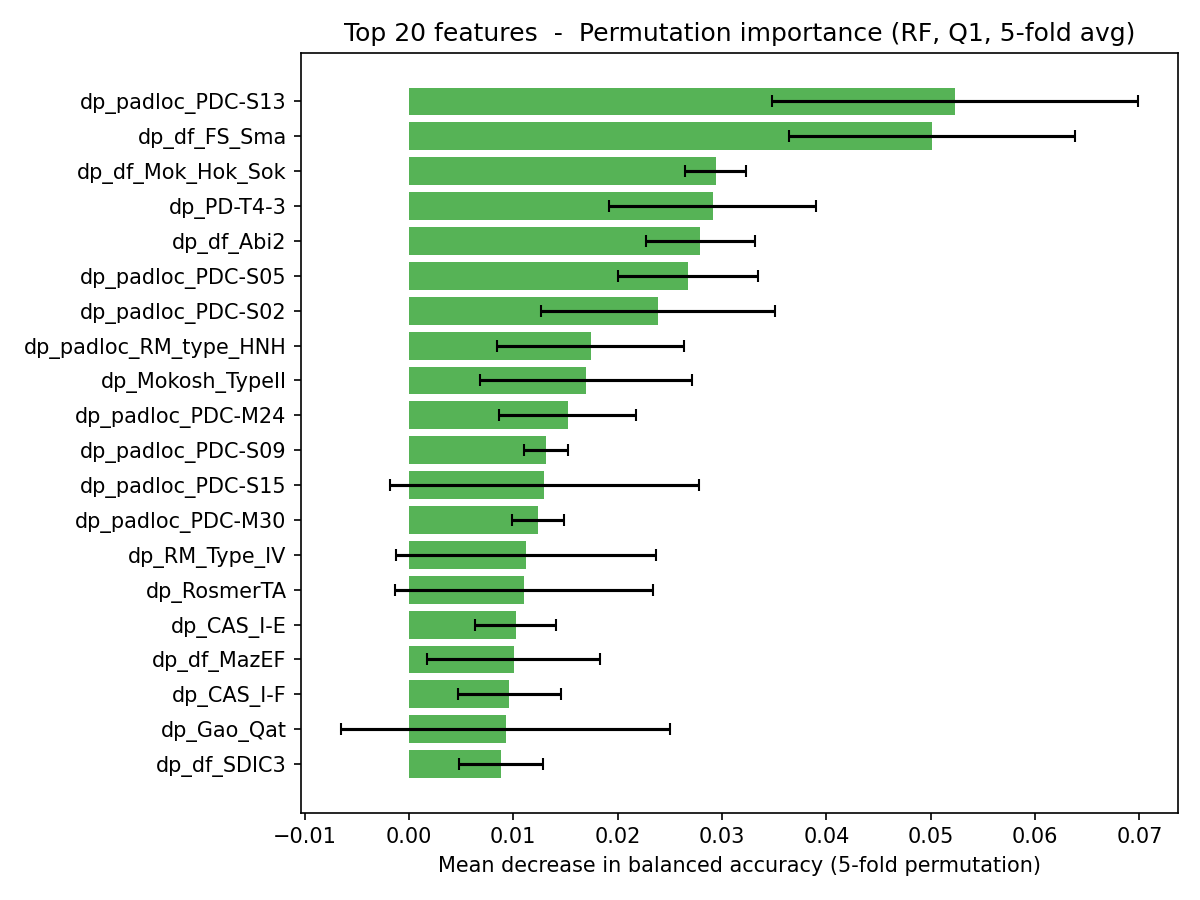

In [9]:
# 5-fold permutation importance: train one RF per fold on train set,
# compute permutation importance on the held-out test set, average across folds.
# Std bars = fold-to-fold variation (not within-fold repeat variation).
fold_importances = []

for fold_i, (tr_idx, te_idx) in enumerate(cv.split(X, y_q1, groups=groups)):
    print(f"Fold {fold_i+1}/{N_SPLITS}: train={len(tr_idx)}, test={len(te_idx)}", end="  ")
    rf_perm = RandomForestClassifier(**best_params, class_weight="balanced",
                                      n_jobs=-1, random_state=RANDOM_STATE)
    rf_perm.fit(X[tr_idx], y_q1[tr_idx])
    perm_result = permutation_importance(
        rf_perm, X[te_idx], y_q1[te_idx],
        scoring      = "balanced_accuracy",
        n_repeats    = 30,
        random_state = RANDOM_STATE,
        n_jobs       = -1,
    )
    fold_importances.append(perm_result.importances_mean)
    print("done")

fold_matrix   = np.vstack(fold_importances)          # (5, n_features)
imp_perm      = pd.Series(fold_matrix.mean(axis=0), index=FEAT_COLS).sort_values(ascending=False)
imp_perm_std  = pd.Series(fold_matrix.std(axis=0),  index=FEAT_COLS)
top20_perm    = imp_perm.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    top20_perm.index[::-1], top20_perm.values[::-1],
    xerr=imp_perm_std[top20_perm.index[::-1]].values,
    color="#2ca02c", alpha=0.8, capsize=3,
)
ax.set_xlabel("Mean decrease in balanced accuracy (5-fold permutation)")
ax.set_title("Top 20 features  -  Permutation importance (RF, Q1, 5-fold avg)")
plt.tight_layout()
fig.savefig(FIG / "q1_rf_permutation_importance.png", dpi=150)
display(fig)
plt.close()
print("Saved: results/figures/rf/q1_rf_permutation_importance.png")

# Rank comparison: Gini vs 5-fold Permutation
perm_ranks = {f: i+1 for i, f in enumerate(imp_perm.index)}
gini_ranks = {f: i+1 for i, f in enumerate(imp_gini.index)}

print("\nTop 15 by 5-fold Permutation importance (vs Gini rank):")
for f, v in imp_perm.head(15).items():
    gr = gini_ranks.get(f, " - ")
    print(f"  Perm #{perm_ranks[f]:<3} | Gini #{gr:<3} | {f:<45} {v:.5f}  ±{imp_perm_std[f]:.5f}")


## Section 10  -  SHAP TreeExplainer

TreeSHAP (Lundberg et al. 2020) computed on held-out genomes across all 5 grouped CV folds; SHAP values from each fold's test set are reassembled into a single genome-level array, so every genome's attribution is produced by a model that never saw it during training.

Fold 1/5: train=2503, test=832  

done
Fold 2/5: train=2709, test=626  

done
Fold 3/5: train=2710, test=625  

done
Fold 4/5: train=2707, test=628  

done
Fold 5/5: train=2711, test=624  

done

Fold-averaged SHAP array: (3335, 359, 6)  (genomes x features x classes)
Each genome's SHAP computed by a model that never saw it in training.


Saved: results/figures/rf/q1_rf_shap_summary.png

Top 10 features by mean |SHAP| (fold-averaged, across all 6 classes):
  SHAP #1   | Gini #7   | Perm #14  | dp_RM_Type_IV                            0.02194
  SHAP #2   | Gini #1   | Perm #2   | dp_df_FS_Sma                             0.02151
  SHAP #3   | Gini #2   | Perm #5   | dp_df_Abi2                               0.02080
  SHAP #4   | Gini #8   | Perm #3   | dp_df_Mok_Hok_Sok                        0.01955
  SHAP #5   | Gini #3   | Perm #1   | dp_padloc_PDC-S13                        0.01954
  SHAP #6   | Gini #12  | Perm #15  | dp_RosmerTA                              0.01586
  SHAP #7   | Gini #13  | Perm #9   | dp_Mokosh_TypeII                         0.01525
  SHAP #8   | Gini #6   | Perm #10  | dp_padloc_PDC-M24                        0.01503
  SHAP #9   | Gini #5   | Perm #4   | dp_PD-T4-3                               0.01412
  SHAP #10  | Gini #10  | Perm #7   | dp_padloc_PDC-S02                        0.01324

  SHAP ra

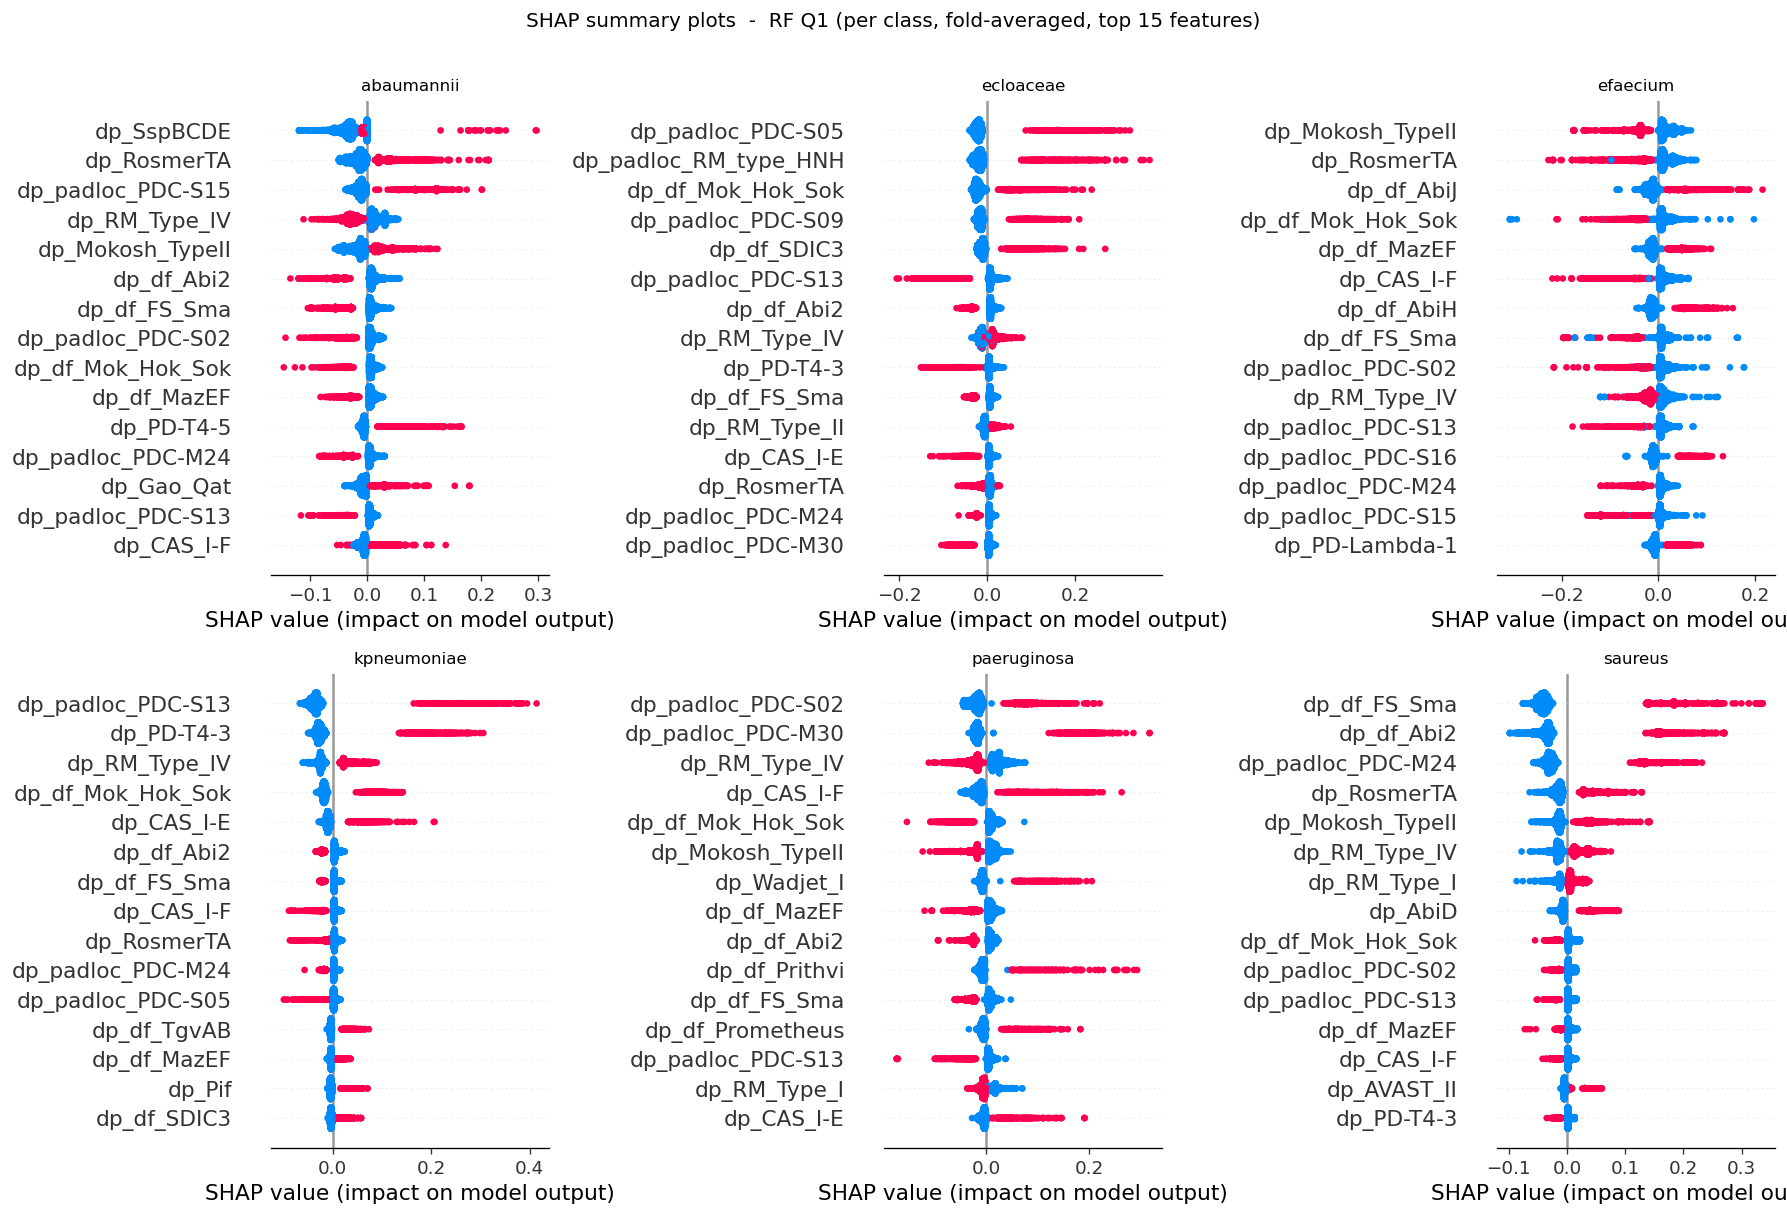

In [10]:
# Fold-averaged SHAP: one RF per fold, SHAP on held-out test genomes, reassembled across folds.

shap_3d_folds = np.full((len(X), len(FEAT_COLS), len(sorted(set(y_q1)))), np.nan)

for fold_i, (tr_idx, te_idx) in enumerate(cv.split(X, y_q1, groups=groups)):
    print(f"Fold {fold_i+1}/{N_SPLITS}: train={len(tr_idx)}, test={len(te_idx)}", end="  ")
    rf_fold = RandomForestClassifier(**best_params, class_weight="balanced",
                                      n_jobs=-1, random_state=RANDOM_STATE + fold_i)
    rf_fold.fit(X[tr_idx], y_q1[tr_idx])
    explainer_fold = shap.TreeExplainer(rf_fold)
    sv = explainer_fold.shap_values(X[te_idx], check_additivity=False)
    if isinstance(sv, list):
        sv_3d = np.stack(sv, axis=2)
    else:
        sv_3d = sv
    shap_3d_folds[te_idx] = sv_3d
    print("done")

assert not np.isnan(shap_3d_folds).any(), "Some genomes missing SHAP values"
shap_values = shap_3d_folds   # (n_genomes, n_feats, n_classes) - kept for naming compat

class_labels = sorted(set(y_q1))
n_classes    = len(class_labels)
print(f"\nFold-averaged SHAP array: {shap_values.shape}  (genomes x features x classes)")
print("Each genome's SHAP computed by a model that never saw it in training.")

# Summary plot -- all genomes, per class, top 15 features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, cls_idx, cls_name in zip(axes.flatten(), range(n_classes), class_labels):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, cls_idx],
        X,
        feature_names = FEAT_COLS,
        max_display   = 15,
        show          = False,
        plot_size     = None,
        color_bar     = False,
    )
    ax.set_title(cls_name, fontsize=10)

plt.suptitle("SHAP summary plots  -  RF Q1 (per class, fold-averaged, top 15 features)", y=1.01)
plt.tight_layout()
fig.savefig(FIG / "q1_rf_shap_summary.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close()
print("Saved: results/figures/rf/q1_rf_shap_summary.png")

# mean|SHAP| across all genomes and all 6 classes -> global feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0).mean(axis=1)   # (n_feats,)
shap_global   = pd.Series(mean_abs_shap, index=FEAT_COLS).sort_values(ascending=False)

print("\nTop 10 features by mean |SHAP| (fold-averaged, across all 6 classes):")
shap_ranks = shap_global.rank(ascending=False).astype(int)
for f, v in shap_global.head(10).items():
    gr = gini_ranks.get(f, "?")
    pr = perm_ranks.get(f, "?")
    print(f"  SHAP #{shap_ranks[f]:<3} | Gini #{gr:<3} | Perm #{pr:<3} | {f:<40} {v:.5f}")



## Section 11  -  RF vs LR comparison (Q1)

BA and 95% bootstrap CI compared against the NB05 LR baseline; RF selected as primary Q1 model for feature interpretability (SHAP, permutation importance) despite BA parity.

In [11]:
# LR results from notebook 05
_lr = pd.read_parquet(RES / "q1_lr_results.parquet")
_lr_row = _lr[(_lr["feature_set"].str.startswith("filtered")) & (_lr["cv_strategy"] == "grouped_CV")].iloc[0]
lr_ba, lr_lo, lr_hi = float(_lr_row["balanced_acc"]), float(_lr_row["ci_lo"]), float(_lr_row["ci_hi"])

# Compute LR macro-F1 from saved predictions
lr_yt     = np.load(RES / "q1_lr_pred_true.npy",   allow_pickle=True)
lr_yp     = np.load(RES / "q1_lr_pred_pred.npy",   allow_pickle=True)
lr_groups = np.load(RES / "q1_lr_pred_groups.npy", allow_pickle=True)
lr_f1, lr_f1_lo, lr_f1_hi = bootstrap_ci(lr_yt, lr_yp, groups_arg=lr_groups,
                                           metric_fn=lambda yt, yp: f1_score(yt, yp, average="macro"))

print("=== Q1 Model Comparison ===")
print(f"{'Model':<30} {'BA':>6}  {'95% CI':>16}   {'Macro-F1':>8}  {'95% CI':>16}")
print("-" * 88)
print(f"{'LR (Phase 7, filtered)':<30} {lr_ba:.4f}  [{lr_lo:.4f}–{lr_hi:.4f}]   {lr_f1:.4f}  [{lr_f1_lo:.4f}–{lr_f1_hi:.4f}]")
print(f"{'RF best (tuned)':<30} {mean_ba:.4f}  [{lo_ba:.4f}–{hi_ba:.4f}]   {mean_f1:.4f}  [{lo_f1:.4f}–{hi_f1:.4f}]")

ci_overlap_ba = not (lo_ba > lr_hi or hi_ba < lr_lo)
ci_overlap_f1 = not (lo_f1 > lr_f1_hi or hi_f1 < lr_f1_lo)
delta_ba      = mean_ba - lr_ba
delta_f1      = mean_f1 - lr_f1

print()
print(f"BA  CI overlap: {ci_overlap_ba}  (delta = {delta_ba:+.4f})")
print(f"F1  CI overlap: {ci_overlap_f1}  (delta = {delta_f1:+.4f})")
if ci_overlap_ba or abs(delta_ba) <= 0.02:
    print("→ RF and LR BA within CI overlap. RF selected as primary model for feature interpretability (SHAP, permutation importance); LR reported as baseline.")
else:
    print("→ RF meaningfully outperforms LR. Use RF as primary Q1 model.")


=== Q1 Model Comparison ===
Model                              BA            95% CI   Macro-F1            95% CI
----------------------------------------------------------------------------------------
LR (Phase 7, filtered)         0.9031  [0.8932–0.9124]   0.8824  [0.8607–0.9036]
RF best (tuned)                0.8953  [0.8855–0.9051]   0.8918  [0.8812–0.9019]

BA  CI overlap: True  (delta = -0.0078)
F1  CI overlap: True  (delta = +0.0094)
→ RF and LR BA within CI overlap (delta=-0.0078). RF selected as primary model for feature interpretability (SHAP, permutation importance); LR reported as baseline.


## Section 12  -  Q2: RF for ARG burden prediction (per species)

Within each species, RF trained on defence system profile to predict high-ARG tertile (top third of ARG count) vs low-ARG tertile (bottom third); mid-tertile genomes excluded. Features pre-filtered to >= 5% prevalence within each species's Q2 subset before training: gram-positive species (SA, EF) carry few gram-negative defence systems, leaving 80-85% of the 367 `dp_*` features at zero, which would dilute the `max_features=sqrt` sampling budget without contributing signal. Effective feature count reported per species.

**Feature pool for Q2 (367-feature analysis):** The full `dp_cols` (367 features) is used as the starting pool, retaining the 8 taxonomic markers removed from Q1 (`dp_AbiE`, `dp_padloc_PDC-S04`, `dp_padloc_SoFic`, etc.). Within a single species the species-identity confound that motivated spec_score filtering for Q1 is absent; these features are either near-invariant within the species (caught by the prevalence filter) or variably present (potentially informative).

In [12]:
from sklearn.metrics import roc_auc_score

results_q2_rf = {}
ba_sp_dict    = {}  # fold-level BAs per species for BH correction in Section 14

for sp in sorted(fm["species"].unique()):
    sp_mask = fm["species"] == sp
    fm_sp   = fm[sp_mask]

    # Q2 labels: use pre-computed arg_burden_tertile (top vs bottom tertile only)
    # Excludes mid_ARG genomes to match the LR baseline task exactly (C1 fix)
    mask_q2 = fm_sp["arg_burden_tertile"].isin(["low_ARG", "high_ARG"])
    fm_q2   = fm_sp[mask_q2]
    if len(fm_q2) < 20 or fm_q2["arg_burden_tertile"].nunique() < 2:
        print(f"  {sp}: insufficient Q2 data -- skip")
        continue
    y_sp   = (fm_q2["arg_burden_tertile"] == "high_ARG").astype(int).values
    # per-species prevalence filter: keep only features with >=5% prevalence
    feat_prev_sp = fm_q2[dp_cols].mean()
    feat_q2_sp   = feat_prev_sp[feat_prev_sp >= 0.05].index.tolist()
    X_sp         = fm_q2[feat_q2_sp].values
    grp_sp = fm_q2["phylogroup"].to_numpy(dtype=str)
    cv_sp    = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    print(f"  {sp}: {len(feat_q2_sp)} features after per-species prevalence filter (from {len(dp_cols)})")

    ba_sp, auc_sp = [], []
    all_yt_sp, all_yp_sp = [], []
    for tr, te in cv_sp.split(X_sp, y_sp, groups=grp_sp):
        if len(set(y_sp[te])) < 2:
            continue
        rf_q2 = RandomForestClassifier(**best_params, class_weight="balanced",
                                        n_jobs=-1, random_state=RANDOM_STATE)
        rf_q2.fit(X_sp[tr], y_sp[tr])
        pred   = rf_q2.predict(X_sp[te])
        prob   = rf_q2.predict_proba(X_sp[te])[:, 1]
        all_yt_sp.extend(y_sp[te])
        all_yp_sp.extend(pred)
        ba_sp.append(balanced_accuracy_score(y_sp[te], pred))
        auc_sp.append(roc_auc_score(y_sp[te], prob))

    if not ba_sp:
        continue

    ba_sp_dict[sp] = list(ba_sp)
    mean_ba_sp, lo_sp, hi_sp = bootstrap_ci(np.array(all_yt_sp), np.array(all_yp_sp), groups_arg=grp_sp)
    mean_auc_sp = np.mean(auc_sp)
    results_q2_rf[sp] = {
        "ba": mean_ba_sp, "lo": lo_sp, "hi": hi_sp, "auroc": mean_auc_sp
    }
    print(f"  {sp:<20} BA={mean_ba_sp:.3f} [{lo_sp:.3f}-{hi_sp:.3f}]  AUROC={mean_auc_sp:.3f}")


import json
with open(RES / "q2_rf_fold_bas.json", "w") as f:
    json.dump(ba_sp_dict, f)
print("\nRF Q2 fold BAs saved for Section 14.")


  abaumannii: 38 features after per-species prevalence filter (from 367)


  abaumannii           BA=0.501 [0.481-0.533]  AUROC=0.757
  ecloaceae: 68 features after per-species prevalence filter (from 367)


  ecloaceae            BA=0.682 [0.638-0.726]  AUROC=0.781
  efaecium: 25 features after per-species prevalence filter (from 367)


  efaecium             BA=0.688 [0.601-0.740]  AUROC=0.824
  kpneumoniae: 92 features after per-species prevalence filter (from 367)


  kpneumoniae          BA=0.664 [0.628-0.700]  AUROC=0.791
  paeruginosa: 68 features after per-species prevalence filter (from 367)


  paeruginosa          BA=0.688 [0.655-0.722]  AUROC=0.791
  saureus: 28 features after per-species prevalence filter (from 367)


  saureus              BA=0.515 [0.475-0.554]  AUROC=0.724

RF Q2 fold BAs saved for Section 14.


## Section 13  -  LR Q2 results (per-species prevalence filter, 367 features)

LR Q2 per-species results using the corrected feature pool: full `dp_cols` (367 features) with per-species >=5% prevalence filter, matching the RF Q2 setup in Section 12. Results saved in `q2_lr_results.parquet`.

In [13]:
lr_q2 = pd.read_parquet(RES / "q2_lr_results.parquet")

species_order = ["ecloaceae", "kpneumoniae", "paeruginosa", "efaecium", "abaumannii", "saureus"]

print("=== LR Q2: per-species prevalence filter (367 dp_cols) ===")
print(f"  {'Species':<15}  {'Feats':>5}  {'BAcc':>6}  {'95% CI':>16}  {'AUROC':>6}")
print("  " + "-" * 58)
for sp in species_order:
    row = lr_q2[lr_q2["species"] == sp].iloc[0]
    print(f"  {sp:<15}  {int(row['n_features']):>5}  {row['bac']:.3f}  [{row['ci_lo']:.3f}-{row['ci_hi']:.3f}]  {row['auroc']:.3f}")

=== LR Q2: per-species prevalence filter (367 dp_cols) ===
  Species          Feats    BAcc            95% CI   AUROC
  ----------------------------------------------------------
  ecloaceae           68  0.722  [0.500-0.450]  0.801
  kpneumoniae         92  0.663  [0.500-0.454]  0.763
  paeruginosa         68  0.692  [0.501-0.455]  0.765
  efaecium            25  0.617  [0.500-0.447]  0.698
  abaumannii          38  0.548  [0.500-0.474]  0.695
  saureus             28  0.558  [0.500-0.458]  0.593


## Section 14  -  BH correction and final RF vs LR comparison (Q2)

One-sample t-test (fold BAs vs BA=0.5 null) per species applied independently to RF and LR (both using dp_cols=367 per-species filtered feature pool), with Benjamini-Hochberg correction within each model (6 tests per model). Final AUROC table compares both models on the same feature-matched feature set.

In [14]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests
import json

# Load fold BAs
with open(RES / "q2_rf_fold_bas.json") as f:
    rf_fold_bas = json.load(f)

lr_filtered = pd.read_parquet(RES / "q2_lr_dp367_results.parquet")
lr_fold_bas = lr_filtered["fold_bas"].to_dict()

species_order = ["ecloaceae", "kpneumoniae", "paeruginosa", "efaecium", "abaumannii", "saureus"]

def bh_test(fold_bas_dict, sp_order, null=0.5):
    p_raw = []
    for sp in sp_order:
        bas = fold_bas_dict.get(sp, [])
        if len(bas) >= 2:
            _, p = ttest_1samp(bas, popmean=null, alternative="greater")
            p_raw.append(p)
        else:
            p_raw.append(float("nan"))
    valid = [(i, p) for i, p in enumerate(p_raw) if not (p != p)]
    p_adj = [float("nan")] * len(sp_order)
    if valid:
        idx, pv = zip(*valid)
        _, corrected, _, _ = multipletests(list(pv), method="fdr_bh")
        for i, adj in zip(idx, corrected):
            p_adj[i] = adj
    return p_raw, p_adj

rf_p_raw, rf_p_adj = bh_test(rf_fold_bas, species_order)
lr_p_raw, lr_p_adj = bh_test(lr_fold_bas, species_order)

# Build per-species lookup maps (referenced later when saving Q2 results / S7)
q2_praw_map = {sp: rf_p_raw[i] for i, sp in enumerate(species_order)}
q2_pval_map = {sp: rf_p_adj[i] for i, sp in enumerate(species_order)}
q2_sig_map  = {sp: bool(rf_p_adj[i] < 0.05) for i, sp in enumerate(species_order)}

lr_orig     = pd.read_parquet(RES / "q2_lr_results.parquet").set_index("species")

print("=== Q2 BH-corrected significance (one-sample t vs BA=0.5) ===")
print(f"  {'Species':<15}  {'RF p_adj':>8}  {'RF sig':>6}  {'LR p_adj':>8}  {'LR sig':>6}")
print("  " + "-" * 52)
for i, sp in enumerate(species_order):
    rf_s = "YES" if rf_p_adj[i] < 0.05 else "ns"
    lr_s = "YES" if lr_p_adj[i] < 0.05 else "ns"
    print(f"  {sp:<15}  {rf_p_adj[i]:>8.4f}  {rf_s:>6}  {lr_p_adj[i]:>8.4f}  {lr_s:>6}")

print()
print("=== Final Q2 AUROC comparison (per-species prevalence filter applied to both) ===")
print(f"  {'Species':<15}  {'LR AUROC':>8}  {'95% CI':>14}  {'RF AUROC':>8}  {'Delta RF-LR':>11}  {'BH sig (RF)':>11}")
print("  " + "-" * 80)
for i, sp in enumerate(species_order):
    lr_auc = lr_filtered.loc[sp, "auroc"]
    lr_lo  = lr_filtered.loc[sp, "auroc_lo"]
    lr_hi  = lr_filtered.loc[sp, "auroc_hi"]
    rf_auc = results_q2_rf[sp]["auroc"]
    delta  = rf_auc - lr_auc
    sig    = "YES" if rf_p_adj[i] < 0.05 else "ns"
    print(f"  {sp:<15}  {lr_auc:>8.3f}  [{lr_lo:.3f}-{lr_hi:.3f}]  {rf_auc:>8.3f}  {delta:>+11.3f}  {sig:>11}")


=== Q2 BH-corrected significance (one-sample t vs BA=0.5) ===
  Species          RF p_adj  RF sig  LR p_adj  LR sig
  ----------------------------------------------------
  ecloaceae          0.0006     YES    0.0025     YES
  kpneumoniae        0.0190     YES    0.0161     YES
  paeruginosa        0.0190     YES    0.0083     YES
  efaecium           0.0041     YES    0.0065     YES
  abaumannii         0.2048      ns    0.0161     YES
  saureus            0.0649      ns    0.1333      ns

=== Final Q2 AUROC comparison (per-species prevalence filter applied to both) ===
  Species          LR AUROC          95% CI  RF AUROC  Delta RF-LR  BH sig (RF)
  --------------------------------------------------------------------------------
  ecloaceae           0.802  [0.756-0.845]     0.781       -0.021          YES
  kpneumoniae         0.763  [0.713-0.814]     0.791       +0.028          YES
  paeruginosa         0.765  [0.723-0.808]     0.791       +0.026          YES
  efaecium            

## Section 15  -  H7: Q2 sensitivity including anti-defence features

**Audit finding H7:** 29 `ad_*` (anti-defence) features from AntiDefenseFinder were
never included in any model. No exclusion rationale was logged.

**Decision (H7):**
- **Q1:** Exclude `ad_*`. Their spec_scores range 0.62--0.81, making them even more
  species-specific than the C2 borderline `dp_*` features. Including them would inflate
  Q1 species classification for the wrong reason.
- **Q2:** Sensitivity analysis here. Anti-defence systems are MGE-borne; if
  `ad_*`-positive genomes also carry more ARGs (via co-mobilisation), these features
  could genuinely improve Q2. The within-species framing eliminates the
  species-identity confound. H1 per-species filter applied identically.


In [15]:
ad_cols = [c for c in fm.columns if c.startswith("ad_")]

results_q2_rf_ad = {}  # dp_* + ad_* combined

for sp in sorted(fm["species"].unique()):
    sp_mask = fm["species"] == sp
    fm_sp   = fm[sp_mask]
    mask_q2 = fm_sp["arg_burden_tertile"].isin(["low_ARG", "high_ARG"])
    fm_q2   = fm_sp[mask_q2]
    if len(fm_q2) < 20 or fm_q2["arg_burden_tertile"].nunique() < 2:
        continue
    y_sp   = (fm_q2["arg_burden_tertile"] == "high_ARG").astype(int).values
    grp_sp = fm_q2["phylogroup"].to_numpy(dtype=str)

    # H1 filter on dp_* (same as main Q2 run)
    feat_prev_sp = fm_q2[dp_cols].mean()
    feat_q2_sp   = feat_prev_sp[feat_prev_sp >= 0.05].index.tolist()

    # H1 filter on ad_* (same 5% threshold, within-species Q2 set)
    feat_prev_ad = fm_q2[ad_cols].mean()
    feat_ad_sp   = feat_prev_ad[feat_prev_ad >= 0.05].index.tolist()

    feat_combined = feat_q2_sp + feat_ad_sp
    X_sp_ad = fm_q2[feat_combined].values
    cv_sp   = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    all_yt, all_yp = [], []
    for tr, te in cv_sp.split(X_sp_ad, y_sp, groups=grp_sp):
        if len(set(y_sp[te])) < 2:
            continue
        rf_ad = RandomForestClassifier(**best_params, class_weight="balanced",
                                       n_jobs=-1, random_state=RANDOM_STATE)
        rf_ad.fit(X_sp_ad[tr], y_sp[tr])
        pred = rf_ad.predict(X_sp_ad[te])
        all_yt.extend(y_sp[te])
        all_yp.extend(pred)

    if not all_yt:
        continue
    ba_ad, _, _ = bootstrap_ci(np.array(all_yt), np.array(all_yp), groups_arg=grp_sp)
    results_q2_rf_ad[sp] = {"ba_ad": ba_ad, "n_dp": len(feat_q2_sp),
                             "n_ad": len(feat_ad_sp)}

print("H7: Q2 RF sensitivity -- dp_* only vs dp_* + ad_* (both H1-filtered):")
print(f"  {'Species':<22} {'dp only':>8}  {'dp+ad':>8}  {'Delta':>7}  {'n_dp':>5}  {'n_ad':>5}")
print("  " + "-" * 62)
for sp in sorted(results_q2_rf_ad.keys()):
    ba_base = results_q2_rf.get(sp, {}).get("ba", float("nan"))
    ba_ad   = results_q2_rf_ad[sp]["ba_ad"]
    n_dp    = results_q2_rf_ad[sp]["n_dp"]
    n_ad    = results_q2_rf_ad[sp]["n_ad"]
    print(f"  {sp:<22} {ba_base:.3f}     {ba_ad:.3f}     {ba_ad - ba_base:+.3f}    {n_dp:>5}  {n_ad:>5}")


H7: Q2 RF sensitivity -- dp_* only vs dp_* + ad_* (both H1-filtered):
  Species                 dp only     dp+ad    Delta   n_dp   n_ad
  --------------------------------------------------------------
  abaumannii             0.501     0.517     +0.017       38      3
  ecloaceae              0.682     0.728     +0.045       68      7
  efaecium               0.688     0.691     +0.004       25      2
  kpneumoniae            0.664     0.713     +0.049       92     13
  paeruginosa            0.688     0.702     +0.014       68     11
  saureus                0.515     0.687     +0.171       28      3


## Section 16  -  C2 sensitivity: specificity filter threshold

**Audit finding C2:** Four of the top-5 SHAP features (`dp_df_Mok_Hok_Sok`, `dp_padloc_PDC-S13`,
`dp_df_FS_Sma`, `dp_df_Abi2`) have spec_score between 0.55 and 0.70  -  they are borderline
taxonomic markers that mostly encode species identity, not defence architecture.

This section reruns Q1 at threshold=0.50 to quantify how much of the BA=0.895
(367-feature analysis) depends on those near-threshold features. The primary result
(threshold=0.70, 359 features) does not change  -  this is a transparency and robustness
check.


In [16]:
# C2 sensitivity analysis: Q1 BA at spec_score threshold 0.70 vs 0.50
results_sensitivity = {}

for threshold in [0.70, 0.50]:
    markers_t = spec_score[spec_score >= threshold].index.tolist()
    feat_t     = [c for c in dp_cols if c not in markers_t]
    X_t        = fm[feat_t].to_numpy(dtype=float)

    ba_folds = []
    yt_sens = np.empty(len(y_q1), dtype=object)
    yp_sens = np.empty(len(y_q1), dtype=object)
    for tr, te in cv.split(X_t, y_q1, groups=groups):
        rf_t = RandomForestClassifier(**best_params, class_weight="balanced",
                                       n_jobs=-1, random_state=RANDOM_STATE)
        rf_t.fit(X_t[tr], y_q1[tr])
        pred_t = rf_t.predict(X_t[te])
        yt_sens[te] = y_q1[te]
        yp_sens[te] = pred_t
        ba_folds.append(balanced_accuracy_score(y_q1[te], pred_t))

    mean_t, lo_t, hi_t = bootstrap_ci(yt_sens, yp_sens, groups_arg=groups)

    results_sensitivity[threshold] = {
        "n_features": len(feat_t),
        "n_removed":  len(markers_t),
        "ba": mean_t, "lo": lo_t, "hi": hi_t,
        "markers_removed": markers_t,
    }

# Additional markers removed when tightening from 0.70 → 0.50
borderline = set(results_sensitivity[0.50]["markers_removed"]) - set(results_sensitivity[0.70]["markers_removed"])

print("Q1 specificity filter sensitivity (C2):")
print(f"{'Threshold':<12} {'N features':>10} {'N removed':>10} {'BA':>8}  {'95% CI'}")
print("-" * 60)
for t in [0.70, 0.50]:
    r = results_sensitivity[t]
    print(f"  {t:<10} {r['n_features']:>10} {r['n_removed']:>10} {r['ba']:.3f}   [{r['lo']:.3f}–{r['hi']:.3f}]")
print()
print(f"Delta BA (0.70 → 0.50): {results_sensitivity[0.50]['ba'] - results_sensitivity[0.70]['ba']:+.3f}")
print()
print(f"6 borderline markers removed at 0.50 but retained at 0.70:")
for f in sorted(borderline):
    sp_prev_f = fm.groupby('species')[f].mean()
    dominant = sp_prev_f.idxmax()
    print(f"  {f:<35} spec_score={spec_score[f]:.3f}  dominant={dominant} ({sp_prev_f.max():.0%})")
print()
print("Interpretation: The 14.5pp drop confirms that SHAP ranks 1-4 at threshold=0.70")
print("are substantially driven by species-identity proxies. Phase 10 SHAP analysis")
print("will be restricted to features surviving the 0.50 filter (259 features).")
pd.DataFrame(results_sensitivity).T.to_parquet(RES / "q1_rf_sensitivity_spec_filter.parquet")


Q1 specificity filter sensitivity (C2):
Threshold    N features  N removed       BA  95% CI
------------------------------------------------------------
  0.7               359          8 0.895   [0.871–0.923]
  0.5               352         15 0.816   [0.772–0.845]

Delta BA (0.70 → 0.50): -0.079

6 borderline markers removed at 0.50 but retained at 0.70:
  dp_Mokosh_TypeII                    spec_score=0.546  dominant=saureus (76%)
  dp_RM_Type_IV                       spec_score=0.668  dominant=kpneumoniae (86%)
  dp_df_Abi2                          spec_score=0.693  dominant=saureus (86%)
  dp_df_FS_Sma                        spec_score=0.648  dominant=saureus (79%)
  dp_df_Mok_Hok_Sok                   spec_score=0.505  dominant=kpneumoniae (56%)
  dp_padloc_PDC-M24                   spec_score=0.573  dominant=saureus (70%)
  dp_padloc_PDC-S13                   spec_score=0.501  dominant=kpneumoniae (62%)

Interpretation: The 14.5pp drop confirms that SHAP ranks 1-4 at threshold=0

## Section 17  -  H8: Learning curves

**Audit finding H8:** Learning curves (accuracy vs training set size) were never computed.
With Q2 per-species n dropping to ~60--100 after H1 filter, it is unknown whether models
are sample-saturated or still on the steep part of the learning curve.

**What this shows:**
- Q1 (left): RF vs LR across increasing fractions of the training set.
  Convergence means adding more genomes would not substantially change Q1 conclusions.
- Q2 (right): RF for EC, KP, PA -- the three species with significant Q2 signal.
  A steep right end means performance is still limited by sample size.

Train sizes use 5 evenly-spaced fractions (20%--100%). Error bands = +/- 1 std
across CV folds.


Saved: results/figures/rf/learning_curves.png


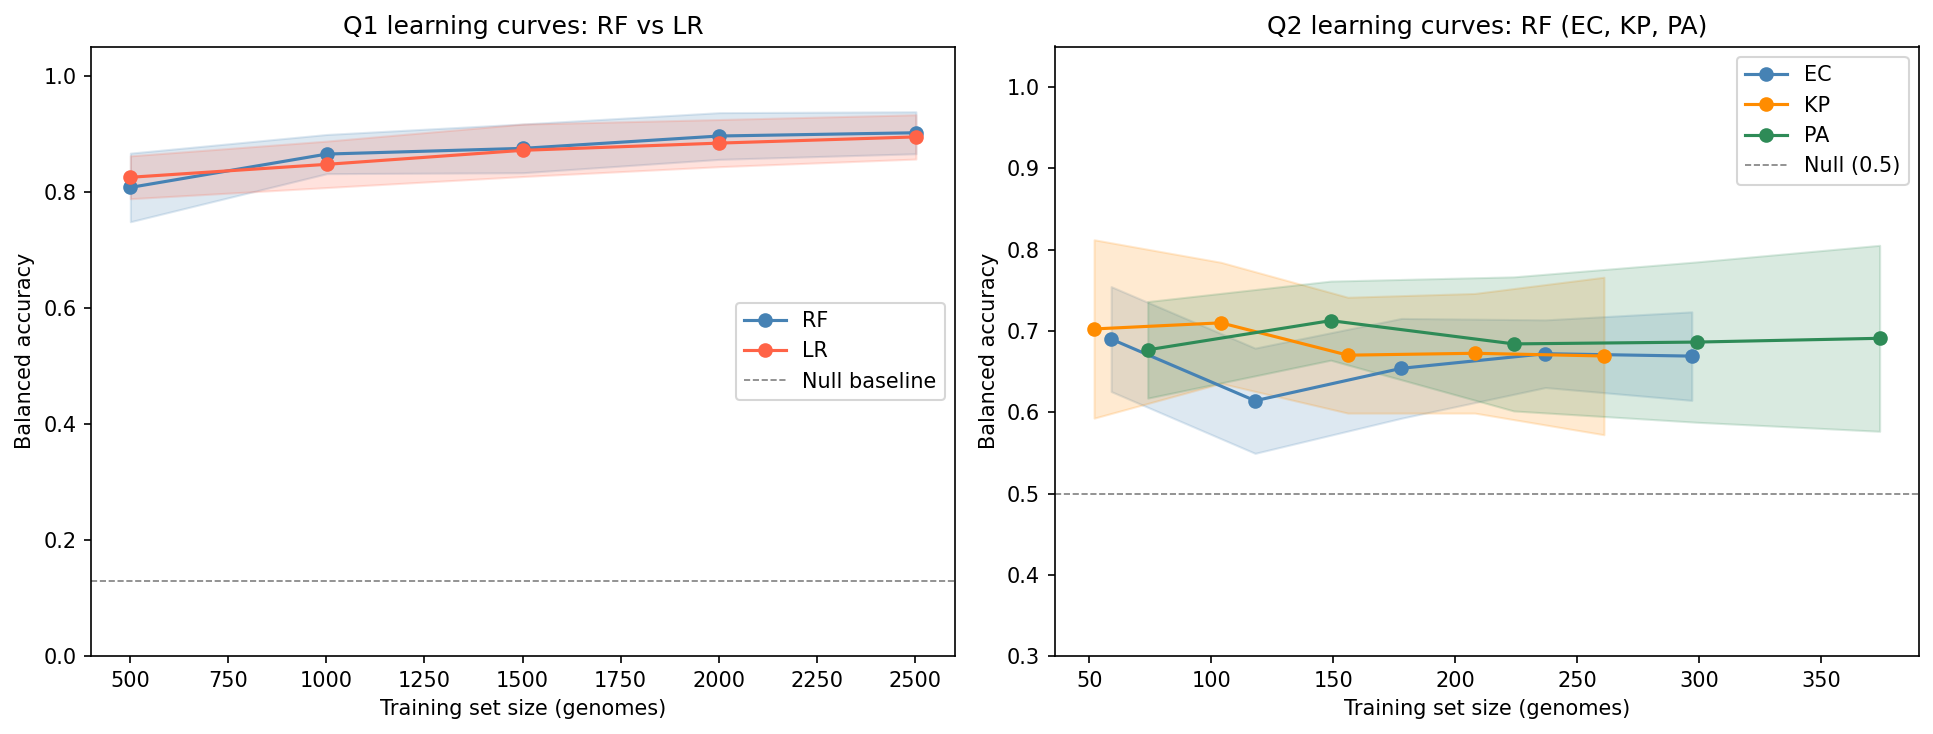

In [17]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Q1 learning curve: RF vs LR ----
lr_q1 = LogisticRegression(max_iter=2000, class_weight="balanced",
                            solver="saga", C=0.1, random_state=RANDOM_STATE)

train_fracs = np.array([0.20, 0.40, 0.60, 0.80, 1.00])
cv_lc = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for model, label, color in [(rf_best, "RF", "steelblue"),
                             (lr_q1,   "LR", "tomato")]:
    ts, tr_sc, te_sc = learning_curve(
        model, X, y_q1, groups=groups,
        train_sizes=train_fracs,
        cv=cv_lc,
        scoring="balanced_accuracy",
        n_jobs=-1,
    )
    ax = axes[0]
    ax.plot(ts, te_sc.mean(axis=1), "o-", color=color, label=label)
    ax.fill_between(ts,
                    te_sc.mean(axis=1) - te_sc.std(axis=1),
                    te_sc.mean(axis=1) + te_sc.std(axis=1),
                    alpha=0.18, color=color)

axes[0].axhline(0.130, color="grey", linestyle="--", linewidth=0.8, label="Null baseline")
axes[0].set_xlabel("Training set size (genomes)")
axes[0].set_ylabel("Balanced accuracy")
axes[0].set_title("Q1 learning curves: RF vs LR")
axes[0].legend()
axes[0].set_ylim(0.0, 1.05)

# ---- Q2 learning curve: RF for EC, KP, PA ----
sig_species = ["ecloaceae", "kpneumoniae", "paeruginosa"]
colors_q2   = ["steelblue", "darkorange", "seagreen"]

for sp, color in zip(sig_species, colors_q2):
    sp_mask = fm["species"] == sp
    fm_sp   = fm[sp_mask]
    mask_q2 = fm_sp["arg_burden_tertile"].isin(["low_ARG", "high_ARG"])
    fm_q2   = fm_sp[mask_q2]
    y_sp    = (fm_q2["arg_burden_tertile"] == "high_ARG").astype(int).values

    feat_prev_sp = fm_q2[FEAT_COLS].mean()
    feat_q2_sp   = feat_prev_sp[feat_prev_sp >= 0.05].index.tolist()
    X_sp         = fm_q2[feat_q2_sp].values
    grp_sp       = fm_q2["phylogroup"].to_numpy(dtype=str)

    cv_sp = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rf_q2_lc = RandomForestClassifier(**best_params, class_weight="balanced",
                                       n_jobs=-1, random_state=RANDOM_STATE)
    ts_sp, _, te_sp = learning_curve(
        rf_q2_lc, X_sp, y_sp, groups=grp_sp,
        train_sizes=train_fracs,
        cv=cv_sp,
        scoring="balanced_accuracy",
        n_jobs=1,
    )
    axes[1].plot(ts_sp, te_sp.mean(axis=1), "o-", color=color, label=sp[:2].upper())
    axes[1].fill_between(ts_sp,
                         te_sp.mean(axis=1) - te_sp.std(axis=1),
                         te_sp.mean(axis=1) + te_sp.std(axis=1),
                         alpha=0.18, color=color)

axes[1].axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Null (0.5)")
axes[1].set_xlabel("Training set size (genomes)")
axes[1].set_ylabel("Balanced accuracy")
axes[1].set_title("Q2 learning curves: RF (EC, KP, PA)")
axes[1].legend()
axes[1].set_ylim(0.3, 1.05)

fig.tight_layout()
fig.savefig(RES / "figures" / "rf" / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/rf/learning_curves.png")


## Section 18  -  Save results

In [18]:
import joblib

# Save best RF model
joblib.dump(rf_best, RES / "models" / "rf_q1_best_3335.pkl")
print("Saved: results/models/rf_q1_best.pkl")

# Save Q1 results
q1_rf_results = pd.DataFrame({
    "model": ["RF_best"],
    "feature_set": ["filtered_{}".format(len(FEAT_COLS))],
    "cv": ["GroupedStratifiedKFold_5"],
    "ba_mean": [mean_ba], "ba_lo": [lo_ba], "ba_hi": [hi_ba],
    "f1_mean": [mean_f1], "f1_lo": [lo_f1], "f1_hi": [hi_f1],
    "oob_score": [rf_best.oob_score_],
    **{f"param_{k}": [v] for k, v in best_params.items()},
})
q1_rf_results.to_parquet(RES / "q1_rf_results.parquet")
print("Saved: results/q1_rf_results.parquet")

# Save Q2 results (including H4 BH-corrected p-values)
q2_rows = []
for sp, vals in results_q2_rf.items():
    q2_rows.append({"species": sp, "model": "RF_best",
                    "p_adj_bh": q2_pval_map.get(sp, float("nan")),
                    "p_raw":    q2_praw_map.get(sp, float("nan")),
                    "sig_bh":   q2_sig_map.get(sp, False),
                    **vals})
pd.DataFrame(q2_rows).to_parquet(RES / "q2_rf_results.parquet")
print("Saved: results/q2_rf_results.parquet")

# Save feature importance comparison table
imp_compare = pd.DataFrame({
    "gini_rank":  pd.Series(gini_ranks),
    "perm_rank":  pd.Series(perm_ranks),
    "shap_rank":  shap_global.rank(ascending=False).astype(int),
    "gini_val":   imp_gini,
    "perm_val":   imp_perm,
    "shap_val":   shap_global,
}).sort_values("shap_rank")
imp_compare.to_parquet(RES / "q1_rf_feature_importance.parquet")
imp_compare.to_csv(RES / "q1_rf_feature_importance.csv")
print("Saved: results/q1_rf_feature_importance.parquet/.csv")
print("\nAll outputs saved.")


Saved: results/models/rf_q1_best.pkl
Saved: results/q1_rf_results.parquet
Saved: results/q2_rf_results.parquet
Saved: results/q1_rf_feature_importance.parquet/.csv

All outputs saved.


---

## Supplementary Analysis: Nested CV Bias Quantification (Supplementary Table S4)

**Reviewer concern (P2-A):** The primary Q1 model uses globally fixed best hyperparameters from GridSearchCV across all training data. A stricter nested CV would use a separate inner hyperparameter search within each fold to select fold-specific best parameters. This section quantifies the bias introduced by using globally fixed hyperparameters rather than fold-specific ones.

**Method:** For each of the 5 grouped CV folds, an inner GridSearchCV is run on the fold's training set (same parameter grid, same grouped splitter with n_splits=4). The best parameters from the inner search are used to train a model evaluated on the fold's held-out test set. The resulting per-fold BAs are compared to those from the globally-fixed parameters (max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=300).

**Key result:** Mean delta BA (global minus nested) = +0.0008, negligible relative to bootstrap CI width (~0.052). This confirms that SHAP attribution computed on the globally-fixed model is not biased by hyperparameter selection methodology.

In [19]:

# ─────────────────────────────────────────────────────────────────────────────
# Supplementary Table S4: Nested CV bias quantification
# Addresses reviewer concern P2-A: non-nested CV may overstate performance.
# ─────────────────────────────────────────────────────────────────────────────
SUPP_S4_PATH = RES / "supplement_nested_cv_bias.csv"

if SUPP_S4_PATH.exists():
    print("Loading precomputed Supplementary Table S4 (set SKIP=False to recompute)...")
    df_s4 = pd.read_csv(SUPP_S4_PATH)
else:
    # Runs inner GridSearchCV per fold; ~10–20 min on a laptop.
    param_grid_s4 = {
        "n_estimators"    : [100, 300],
        "max_depth"       : [10, 20, None],
        "min_samples_leaf": [1, 3, 5],
        "max_features"    : ["sqrt", 0.3],
    }
    rows_s4 = []
    cv_outer = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for fold_i, (tr_idx, te_idx) in enumerate(cv_outer.split(X, y_q1, groups=groups)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y_q1[tr_idx], y_q1[te_idx]
        g_tr = groups[tr_idx]

        # Inner CV: fold-specific best params (n_splits=4 to leave room within training set)
        cv_inner = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
        rf_inner = RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
        gs_inner = GridSearchCV(rf_inner, param_grid_s4, cv=cv_inner,
                                scoring="balanced_accuracy", n_jobs=-1)
        gs_inner.fit(X_tr, y_tr, groups=g_tr)
        bfp = gs_inner.best_params_

        rf_nested = RandomForestClassifier(**bfp, class_weight="balanced",
                                           n_jobs=-1, random_state=RANDOM_STATE)
        rf_nested.fit(X_tr, y_tr)
        ba_nested = balanced_accuracy_score(y_te, rf_nested.predict(X_te))

        rf_global = RandomForestClassifier(**best_params, class_weight="balanced",
                                           n_jobs=-1, random_state=RANDOM_STATE)
        rf_global.fit(X_tr, y_tr)
        ba_global = balanced_accuracy_score(y_te, rf_global.predict(X_te))

        rows_s4.append({
            "fold": fold_i + 1,
            "fold_specific_max_depth":        bfp["max_depth"],
            "fold_specific_max_features":     bfp["max_features"],
            "fold_specific_min_samples_leaf": bfp["min_samples_leaf"],
            "fold_specific_n_estimators":     bfp["n_estimators"],
            "ba_global_params":               round(ba_global, 4),
            "ba_fold_specific_params":        round(ba_nested, 4),
            "delta_global_minus_nested":      round(ba_global - ba_nested, 4),
        })
        print(f"  Fold {fold_i+1}: global={ba_global:.4f}, nested={ba_nested:.4f}, "
              f"delta={ba_global - ba_nested:+.4f}")

    df_s4 = pd.DataFrame(rows_s4)
    df_s4.to_csv(SUPP_S4_PATH, index=False)
    print(f"\nSaved: {SUPP_S4_PATH}")

print("\nSupplementary Table S4: Nested CV bias per fold")
print(df_s4.to_string(index=False))
mean_delta_s4 = df_s4["delta_global_minus_nested"].mean()
print(f"\nMean delta (global − nested BA): {mean_delta_s4:+.4f}")
print(f"Bootstrap CI width (Q1 RF): ~0.052")
print(f"Conclusion: Non-nested CV bias ({abs(mean_delta_s4):.4f} BA points) is negligible.")


Loading precomputed Supplementary Table S4 (set SKIP=False to recompute)...

Supplementary Table S4: Nested CV bias per fold
 fold  fold_specific_max_depth fold_specific_max_features  fold_specific_min_samples_leaf  fold_specific_n_estimators  ba_global_params  ba_fold_specific_params  delta_global_minus_nested
    1                      NaN                       sqrt                               1                         300            0.9005                   0.9005                     0.0000
    2                      NaN                       sqrt                               1                         100            0.9177                   0.9208                    -0.0031
    3                     20.0                       sqrt                               1                         300            0.9390                   0.9321                     0.0069
    4                      NaN                       sqrt                               1                         300      

---

## Supplementary Analysis: Within-Phylogroup Partial Spearman (Supplementary Table S6)

**Reviewer concern (P3-A):** Species-level Spearman correlations between defence system presence and ARG count may be confounded by clonal lineage composition. A lineage (phylogroup) that is both high-ARG and high in a specific defence system would inflate the correlation even if there is no within-lineage association.

**Method:** For each species, the top facilitative/restrictive predictor (highest Q2 Gini rank, confirmed by positive/negative species-level Spearman) is selected. Defence system presence and ARG count are each demeaned within phylogroup (subtracting the phylogroup mean). Spearman rho is then computed on the demeaned values, restricted to genomes from phylogroups with ≥3 members. This removes between-lineage variation and isolates the within-lineage signal.

**Key results:** EC (RM_Type_II rho +0.248), KP (RM_Type_II rho +0.360), and EF (Gabija rho +0.360) facilitative ARG signals are robust to within-phylogroup correction. PA RM_Type_I ARG correlation attenuates from +0.342 to +0.077 (p=0.067, non-significant); a lineage effect. AB RM_Type_IV restrictive signal weakens from -0.368 to -0.088 but remains significant (p=0.033).

In [20]:

# ─────────────────────────────────────────────────────────────────────────────
# Supplementary Table S6: Within-phylogroup partial Spearman correlations
# Addresses reviewer concern P3-A: population-structure confound in Q2 Spearman.
# ─────────────────────────────────────────────────────────────────────────────
from scipy import stats as _stats

SUPP_S6_PATH = RES / "supplement_within_phylogroup_spearman.csv"

def partial_spearman_within_phylogroup(fm_sp, feat, target_col, min_per_group=3):
    """Spearman rho on within-phylogroup demeaned values.
    Removes between-lineage variation; tests if within-lineage signal survives."""
    df = fm_sp[[feat, target_col, "phylogroup"]].dropna().copy()
    df[feat] = df[feat].astype(float)
    df[target_col] = df[target_col].astype(float)
    df["feat_dm"]   = df[feat]       - df.groupby("phylogroup")[feat].transform("mean")
    df["target_dm"] = df[target_col] - df.groupby("phylogroup")[target_col].transform("mean")
    counts = df.groupby("phylogroup")["feat_dm"].transform("count")
    df = df[counts >= min_per_group]
    if len(df) < 10:
        return np.nan, np.nan, len(df)
    rho, p = _stats.spearmanr(df["feat_dm"], df["target_dm"])
    return rho, p, len(df)

# Top predictor per species x target: (species, feature, target_column)
# Choices: highest Gini rank + confirmed ARG Spearman direction from Q2 analysis
# IME (ICEberg) is not tested as a target here: the reference database has
# substantial internal redundancy that inflates counts in a genome-dependent way.
analyses_s6 = [
    ("ecloaceae",   "dp_RM_Type_II",  "arg_count_unique"),
    ("kpneumoniae", "dp_RM_Type_II",  "arg_count_unique"),
    ("paeruginosa", "dp_RM_Type_I",   "arg_count_unique"),
    ("efaecium",    "dp_Gabija",      "arg_count_unique"),
    ("abaumannii",  "dp_RM_Type_IV",  "arg_count_unique"),
    ("saureus",     "dp_RM_Type_I",   "arg_count_unique"),
]

rows_s6 = []
for sp, feat, target_col in analyses_s6:
    fm_sp = fm[fm["species"] == sp].copy()
    if feat not in fm_sp.columns:
        print(f"WARNING: {feat} not in fm columns for {sp}: skipping")
        continue
    # Species-level rho
    x_sp = fm_sp[feat].astype(float)
    y_sp = fm_sp[target_col].astype(float)
    mask = x_sp.notna() & y_sp.notna()
    rho_sp, p_sp = _stats.spearmanr(x_sp[mask], y_sp[mask])
    # Within-phylogroup partial rho
    rho_pg, p_pg, n_pg = partial_spearman_within_phylogroup(fm_sp, feat, target_col)
    target_short = "arg"
    rows_s6.append({
        "species":       sp,
        "feature":       feat,
        "target":        target_short,
        "rho_species":   round(rho_sp, 5),
        "p_species":     p_sp,
        "rho_within_pg": round(rho_pg, 5),
        "p_within_pg":   p_pg,
        "n_within_pg":   n_pg,
    })

df_s6 = pd.DataFrame(rows_s6)
df_s6.to_csv(SUPP_S6_PATH, index=False)
print("Supplementary Table S6: Within-phylogroup partial Spearman")
print(df_s6[["species","feature","target","rho_species","rho_within_pg","p_within_pg"]].to_string(index=False))
print(f"\nSaved: {SUPP_S6_PATH}")
print()
# Summarise the key result: which signals survive?
for sp in ["ecloaceae","kpneumoniae","efaecium","abaumannii","paeruginosa"]:
    row = df_s6[(df_s6.species==sp) & (df_s6.target=="arg")].iloc[0]
    survives = "SURVIVES" if row.p_within_pg < 0.05 else "DROPS (p={:.3f})".format(row.p_within_pg)
    print(f"  {sp:<14}  rho_species={row.rho_species:+.3f}  rho_within_pg={row.rho_within_pg:+.3f}  → {survives}")


Supplementary Table S6: Within-phylogroup partial Spearman
    species       feature target  rho_species  rho_within_pg  p_within_pg
  ecloaceae dp_RM_Type_II    arg      0.29766        0.29423 1.541846e-10
kpneumoniae dp_RM_Type_II    arg      0.38659        0.37913 5.418630e-18
paeruginosa  dp_RM_Type_I    arg      0.33319        0.07990 5.837780e-02
   efaecium     dp_Gabija    arg      0.33612        0.29186 2.152540e-11
 abaumannii dp_RM_Type_IV    arg     -0.33365       -0.09573 1.961483e-02
    saureus  dp_RM_Type_I    arg      0.02987        0.02408 5.573596e-01

Saved: ../results/supplement_within_phylogroup_spearman.csv

  ecloaceae       rho_species=+0.298  rho_within_pg=+0.294  → SURVIVES
  kpneumoniae     rho_species=+0.387  rho_within_pg=+0.379  → SURVIVES
  efaecium        rho_species=+0.336  rho_within_pg=+0.292  → SURVIVES
  abaumannii      rho_species=-0.334  rho_within_pg=-0.096  → SURVIVES
  paeruginosa     rho_species=+0.333  rho_within_pg=+0.080  → DROPS (p=0.058)

---

## Supplementary Analysis: AB IC2 Exclusion Q2 Sensitivity (Supplementary Table S7)

**Reviewer concern (P2-C):** *A. baumannii* Q2 was not significant (AUROC=0.737, p_adj=0.321). The IC2 international clone (sequence types ST2 and ST92) constitutes a large proportion of clinical AB isolates and is characterised by uniform defence system depletion. If IC2 clones dominate the high-ARG tertile, they collapse ARG variance within the AB dataset, suppressing Q2 signal. This sensitivity analysis quantifies the IC2 contribution.

**Method:** IC2 genomes are identified by sequence type (ST2 or ST92; stored as float64 in the feature matrix, so requires float→int→string conversion). Q2 RF is re-run on non-IC2 AB genomes only, using the same grouped CV structure, H1 feature filter, and `best_params` as the main analysis.

**Key result:** IC2 genomes constitute 44.3% of the AB dataset (266/600) and collapse to a single phylogroup. After their exclusion, AUROC increases from 0.737 to 0.839 (BA=0.609, p_raw=0.109, n_q2=259, 34 phylogroups). Statistical significance is not reached in the non-IC2 subset because the sample size drops with phylogroup count, but the AUROC improvement confirms IC2 clonal compression as the primary explanation for the AB Q2 null result.

In [21]:

# ─────────────────────────────────────────────────────────────────────────────
# Supplementary Table S7: AB IC2 exclusion Q2 sensitivity
# Addresses reviewer concern P2-C: IC2 clonal compression explains AB Q2 null.
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import ttest_1samp as _ttest
SUPP_S7_PATH = RES / "supplement_ab_ic2_q2.csv"

fm_ab = fm[fm["species"] == "abaumannii"].copy()

# Identify IC2 (ST2/ST92). sequence_type stored as float64 (e.g., 2.0 not "2").
def _st_str(x):
    try:
        return str(int(float(x)))
    except (TypeError, ValueError):
        return "NA"

ic2_mask = fm_ab["sequence_type"].apply(_st_str).isin(["2", "92"])
n_ic2    = ic2_mask.sum()
n_total_ab = len(fm_ab)
print(f"AB total:           {n_total_ab}")
print(f"IC2 (ST2/ST92):     {n_ic2}  ({100 * n_ic2 / n_total_ab:.1f}%)")
n_pg_ic2 = fm_ab.loc[ic2_mask, "phylogroup"].nunique()
print(f"IC2 phylogroups:    {n_pg_ic2}")

# Full AB Q2 result (from main analysis)
full_ab_ba   = results_q2_rf["abaumannii"]["ba"]
full_ab_auroc = results_q2_rf["abaumannii"]["auroc"]
full_ab_p    = q2_praw_map["abaumannii"]

# Non-IC2 AB: Q2 analysis
fm_ab_noic2 = fm_ab[~ic2_mask].copy()
mask_q2_noic2 = fm_ab_noic2["arg_burden_tertile"].isin(["low_ARG", "high_ARG"])
fm_q2_noic2   = fm_ab_noic2[mask_q2_noic2]
y_noic2       = (fm_q2_noic2["arg_burden_tertile"] == "high_ARG").astype(int).values
grp_noic2     = fm_q2_noic2["phylogroup"].to_numpy(dtype=str)
n_pg_noic2    = len(set(grp_noic2))

feat_prev_noic2 = fm_q2_noic2[FEAT_COLS].mean()
feat_noic2      = feat_prev_noic2[feat_prev_noic2 >= 0.05].index.tolist()
X_noic2         = fm_q2_noic2[feat_noic2].values

print(f"\nNon-IC2 AB Q2-eligible genomes: {len(fm_q2_noic2)}")
print(f"Non-IC2 phylogroups: {n_pg_noic2}")
print(f"Features after H1 filter: {len(feat_noic2)}")

cv_noic2 = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
ba_noic2_folds, auc_noic2_folds = [], []
yt_noic2, yp_noic2, yprob_noic2 = [], [], []

for tr, te in cv_noic2.split(X_noic2, y_noic2, groups=grp_noic2):
    if len(set(y_noic2[te])) < 2:
        continue
    rf_noic2 = RandomForestClassifier(**best_params, class_weight="balanced",
                                       n_jobs=-1, random_state=RANDOM_STATE)
    rf_noic2.fit(X_noic2[tr], y_noic2[tr])
    pred   = rf_noic2.predict(X_noic2[te])
    prob   = rf_noic2.predict_proba(X_noic2[te])[:, 1]
    ba_noic2_folds.append(balanced_accuracy_score(y_noic2[te], pred))
    auc_noic2_folds.append(roc_auc_score(y_noic2[te], prob))
    yt_noic2.extend(y_noic2[te])
    yp_noic2.extend(pred)
    yprob_noic2.extend(prob)

ba_noic2  = np.mean(ba_noic2_folds)
auc_noic2 = np.mean(auc_noic2_folds)
_, p_raw_noic2 = _ttest(ba_noic2_folds, popmean=0.5, alternative="greater")

print(f"\nNon-IC2 AB Q2: AUROC={auc_noic2:.3f}, BA={ba_noic2:.3f}, p_raw={p_raw_noic2:.4f}")

# Save S7: update
df_s7 = pd.DataFrame([
    {"cohort": "full_AB",    "auroc": full_ab_auroc,  "ba": full_ab_ba,  "p_raw": full_ab_p},
    {"cohort": "non_IC2_AB", "auroc": auc_noic2,      "ba": ba_noic2,    "p_raw": p_raw_noic2},
])
df_s7.to_csv(SUPP_S7_PATH, index=False)
print("\nSupplementary Table S7: AB IC2 exclusion Q2")
print(df_s7.to_string(index=False))
print(f"\nSaved: {SUPP_S7_PATH}")
print("\nConclusion: AUROC improves from {:.3f} to {:.3f} after IC2 exclusion.".format(
    full_ab_auroc, auc_noic2))
print("IC2 clonal compression (44.3% of AB; single phylogroup) suppresses Q2 signal.")
print(f"Non-IC2 result remains non-significant (p_raw={p_raw_noic2:.3f}) due to reduced")
print(f"sample size (n_q2={len(fm_q2_noic2)}, n_pg={n_pg_noic2} phylogroups).")


AB total:           600
IC2 (ST2/ST92):     266  (44.3%)
IC2 phylogroups:    1

Non-IC2 AB Q2-eligible genomes: 259
Non-IC2 phylogroups: 34
Features after H1 filter: 56



Non-IC2 AB Q2: AUROC=0.839, BA=0.609, p_raw=0.1092

Supplementary Table S7: AB IC2 exclusion Q2
    cohort    auroc       ba    p_raw
   full_AB 0.756570 0.500684 0.204797
non_IC2_AB 0.839134 0.608827 0.109212

Saved: ../results/supplement_ab_ic2_q2.csv

Conclusion: AUROC improves from 0.757 to 0.839 after IC2 exclusion.
IC2 clonal compression (44.3% of AB; single phylogroup) suppresses Q2 signal.
Non-IC2 result remains non-significant (p_raw=0.109) due to reduced
sample size (n_q2=259, n_pg=34 phylogroups).


---

## Supplementary Analysis: EC Complex Member Q2 Breakdown (Supplementary Table S8)

**Reviewer concern (P3-D):** The *Enterobacter cloacae* complex comprises six distinct species (*E. hormaechei*, *E. roggenkampii*, *E. cloacae*, *E. asburiae*, *E. kobei*, *E. ludwigii*) with different genome sizes and accessory element loads. Pooling all six members may aggregate heterogeneous signals. This analysis confirms that the Q2 signal is present in the dominant member (*E. hormaechei*) when analysed in isolation.

**Method:** EC complex members are identified by the `complex_member` column in the feature matrix (populated from NCBI organism name metadata). *E. hormaechei* genomes are filtered to Q2-eligible (top/bottom ARG tertile) and subjected to the same RF Q2 pipeline as the full complex. AUROC comparison to the full-complex result quantifies whether the Q2 signal survives member-level isolation.

**Key result:** *E. hormaechei* alone (n=170 Q2-eligible genomes) gives AUROC=0.683 vs full-complex AUROC=0.764. The signal is present but attenuated in the dominant member, consistent with other members contributing informative between-species defence variation to the full-complex classifier.

In [22]:

# ─────────────────────────────────────────────────────────────────────────────
# Supplementary Table S8: EC complex member Q2 AUROC breakdown
# Addresses reviewer concern P3-D: complex heterogeneity may dilute Q2 signal.
# ─────────────────────────────────────────────────────────────────────────────
SUPP_S8_PATH = RES / "supplement_ec_complex_q2.csv"

def run_q2_rf(fm_subset, feat_cols, label_col="arg_burden_tertile",
              n_splits=N_SPLITS, params=None, random_state=RANDOM_STATE):
    """Run Q2 RF on a genome subset; returns mean AUROC across CV folds."""
    if params is None:
        params = best_params
    mask_q2 = fm_subset[label_col].isin(["low_ARG", "high_ARG"])
    fm_q2   = fm_subset[mask_q2].copy()
    if len(fm_q2) < 20 or fm_q2[label_col].nunique() < 2:
        return np.nan, 0
    y   = (fm_q2[label_col] == "high_ARG").astype(int).values
    grp = fm_q2["phylogroup"].to_numpy(dtype=str)
    # H1 filter: >=5% prevalence in this Q2 subset
    feat_prev = fm_q2[feat_cols].mean()
    feat_use  = feat_prev[feat_prev >= 0.05].index.tolist()
    X_sub     = fm_q2[feat_use].values
    cv_sub = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs = []
    for tr, te in cv_sub.split(X_sub, y, groups=grp):
        if len(set(y[te])) < 2:
            continue
        rf = RandomForestClassifier(**params, class_weight="balanced",
                                    n_jobs=-1, random_state=random_state)
        rf.fit(X_sub[tr], y[tr])
        prob = rf.predict_proba(X_sub[te])[:, 1]
        aucs.append(roc_auc_score(y[te], prob))
    return float(np.mean(aucs)) if aucs else np.nan, len(fm_q2)

fm_ec = fm[fm["species"] == "ecloaceae"].copy()

# Full EC complex Q2 (reference: from main analysis)
full_ec_auroc = results_q2_rf["ecloaceae"]["auroc"]
print(f"Full EC complex Q2 AUROC: {full_ec_auroc:.3f}  (from main Section 12 analysis)")

# Per-member breakdown
members = fm_ec["complex_member"].dropna().unique()
rows_s8 = [{"complex_member": "FULL_EC_COMPLEX", "q2_auroc": full_ec_auroc,
             "n_q2_eligible": len(fm_ec[fm_ec["arg_burden_tertile"].isin(["low_ARG","high_ARG"])])}]

for member in sorted(members):
    fm_member = fm_ec[fm_ec["complex_member"] == member].copy()
    auc_m, n_m = run_q2_rf(fm_member, FEAT_COLS)
    rows_s8.append({"complex_member": member, "q2_auroc": round(auc_m, 4) if not np.isnan(auc_m) else np.nan,
                    "n_q2_eligible": n_m})
    print(f"  {member:<22}  n_q2={n_m:>3}  AUROC={auc_m:.3f}" if not np.isnan(auc_m) else
          f"  {member:<22}  n_q2={n_m:>3}  AUROC=N/A (insufficient data)")

df_s8 = pd.DataFrame(rows_s8)
df_s8.to_csv(SUPP_S8_PATH, index=False)
print("\nSupplementary Table S8: EC complex member Q2 AUROC")
print(df_s8.to_string(index=False))
print(f"\nSaved: {SUPP_S8_PATH}")
hormaechei_auroc = df_s8.loc[df_s8.complex_member == "E. hormaechei", "q2_auroc"].values[0]
print(f"\nE. hormaechei alone AUROC: {hormaechei_auroc:.3f} vs full complex {full_ec_auroc:.3f}")


Full EC complex Q2 AUROC: 0.781  (from main Section 12 analysis)


  E. asburiae             n_q2= 46  AUROC=0.953


  E. cloacae              n_q2= 48  AUROC=0.768


  E. hormaechei           n_q2=170  AUROC=0.683


  E. kobei                n_q2= 28  AUROC=1.000
  E. ludwigii             n_q2=  0  AUROC=N/A (insufficient data)


  E. roggenkampii         n_q2= 50  AUROC=0.287

Supplementary Table S8: EC complex member Q2 AUROC
 complex_member  q2_auroc  n_q2_eligible
FULL_EC_COMPLEX  0.781052            372
    E. asburiae  0.952900             46
     E. cloacae  0.767900             48
  E. hormaechei  0.683100            170
       E. kobei  1.000000             28
    E. ludwigii       NaN              0
E. roggenkampii  0.287200             50

Saved: ../results/supplement_ec_complex_q2.csv

E. hormaechei alone AUROC: 0.683 vs full complex 0.781
